Answers for Week 4

* Name: Noah Demmenie
* Username: ndemmenie
* Student s-number: S6294588
* Group (AS1, etc.): AS3

**Question 4.1 : List comprehension:**

In [1]:
x = [1,2,3,10]
y = [10, 20, 30, 40]
z = zip(x, y)
xy = []

for x, y in z:
    xy.append(x + y)

print(f"x + y = {xy}")

x + y = [11, 22, 33, 50]


One liner

In [2]:
x = [1,2,3,10]
y = [10, 20, 30, 40]
xy = [x + y for x, y in zip(x, y)]
print(f"x + y = {xy}")

x + y = [11, 22, 33, 50]


With map()

In [3]:
def add(x, y):
    return x + y

x = [1,2,3,10]
y = [10, 20, 30, 40]
xy = map(add, x, y)

print(f"x + y = {list(xy)}")

x + y = [11, 22, 33, 50]


**Question 4.3 : Game making: Rock-Paper-Scissors:**

In [4]:
import numpy as np

# User input

user_input = input("Type R for rock, P for paper or S for scissors:")

# Computer input

computer_input = np.random.choice(['R', 'P', 'S'])

print(f"Computer chose: {computer_input}")

# Judging result

if user_input == computer_input:
    print("Tie!")
elif user_input == 'R' and computer_input == 'P' or user_input == 'S' and computer_input == 'R' or user_input == 'P' and computer_input == 'S' :
    print("You lose!")
else:
    print("You win!")

Type R for rock, P for paper or S for scissors: S


Computer chose: S
Tie!


**Question 4.4 : Simulating measurements and statistical analysis:**

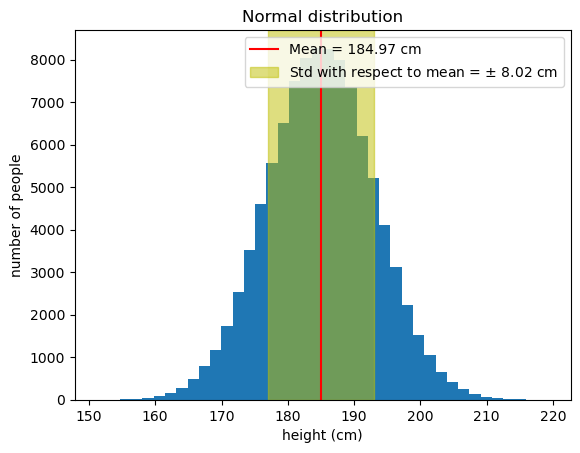

P(196 <_ h) = 0.9154163444567309
P(176.94 <_ h <_ 192.99) = 0.6826894921370861


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Computing distribution, mean and std

distr = np.random.normal(185, 8, 100000)
mean_distr = np.mean(distr)
std_distr = np.std(distr)

# Plotting distribution, mean and std

plt.hist(distr, bins=40)
plt.xlabel("height (cm)")
plt.ylabel("number of people")
plt.title("Normal distribution")
plt.axvline(mean_distr, color = 'r', label = f"Mean = {mean_distr:.2f} cm")
plt.axvspan(mean_distr - std_distr, mean_distr + std_distr, color = 'y', label = rf"Std with respect to mean = $\pm$ {std_distr:.2f} cm", alpha = 0.5)
plt.legend()
plt.show()

# Computing probabilities

X = 196
prob1 = scipy.stats.norm.cdf(X, loc = mean_distr, scale = std_distr)
prob_upperbound = scipy.stats.norm.cdf(mean_distr + std_distr, loc=mean_distr, scale=std_distr)
prob_lowerbound = scipy.stats.norm.cdf(mean_distr - std_distr, loc=mean_distr, scale=std_distr)
prob2 = prob_upperbound - prob_lowerbound
print(f"P({X} <_ h) = {prob1}")
print(f"P({(mean_distr - std_distr):.2f} <_ h <_ {(mean_distr + std_distr):.2f}) = {prob2}")


**Question 4.6 : Integral with Monte Carlo:**

In [6]:
import numpy as np
from numpy import *

# Defining variables

fun = input("Enter a function f(x)=")
a = eval(input("Enter startpoint for integral:"))
b = eval(input("Enter endpoint for integral:"))
n = int(input("Enter number of points for integral:")) 
x = np.random.uniform(a, b, n)

# Evaluating users function

def f(x):
    return eval(fun)

# Computing integral

integral = ((b - a) / n)*np.sum(f(x))
print(f"Integral of {fun} from {a} to {b} with {n} points = {integral}")

Enter a function f(x)= x
Enter startpoint for integral: 0
Enter endpoint for integral: 1
Enter number of points for integral: 10


Integral of x from 0 to 1 with 10 points = 0.5834465216487639


**Question 4.12 : Rotate a square:**

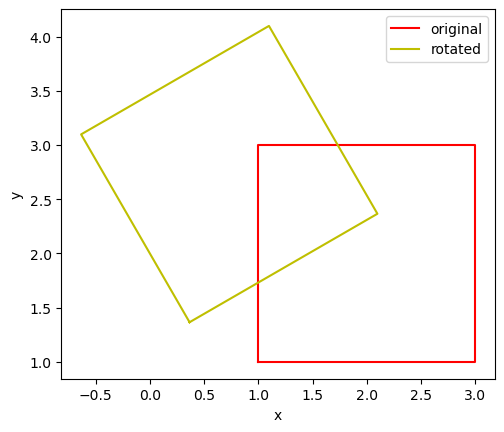

In [7]:
import math
import matplotlib.pyplot as plt

# Compute rotor

angle_degs = 30
theta = math.radians(angle_degs)

rotor = math.cos(theta) + 1j*math.sin(theta)

# Define arrays

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

# Rotate arrays

z = x + 1j*y

zr = rotor * z
xr = zr.real
yr = zr.imag

plt.plot(x, y, label = "original", color = "r")
plt.plot(xr, yr, label = "rotated", color = "y")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect(1)
plt.show()

**Question 4.14 : Passing functions as arguments:**

In [8]:
import numpy as np

def funcfilter(func, seq):
    arr = np.asarray(seq)
    seq_new = arr[arr > 0]
    return func(seq_new)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

sq = 100
result = funcfilter(np.log10, sq)
print("Result log10:", result)

Result log10: [1. 2.]
Result log10: [2.]


**Question 4.16 : Calculating integration using quad():**

In [9]:
from astropy.cosmology import Planck18
from astropy import units as u
from math import sqrt
import scipy

# Import constants with most convenient units

H0 = Planck18.H0.to(u.s**-1).value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

# Define function part of lookback time in s

def tl(z):
    H = H0 * sqrt(Om0*((1+z)**3)+Ode0)
    return 1/((1+z)*H)

# Define integral part of lookback time in s

z = 2    
integral = scipy.integrate.quad(tl, 0, z)

# Convert from s to Gyr

t_s = integral[0] * u.s
t_gyr = t_s.to(u.Gyr)
print(f"tL({z}) = {t_gyr:.2f}")

tL(2) = 10.53 Gyr


**Question 4.21 : Histograms:**

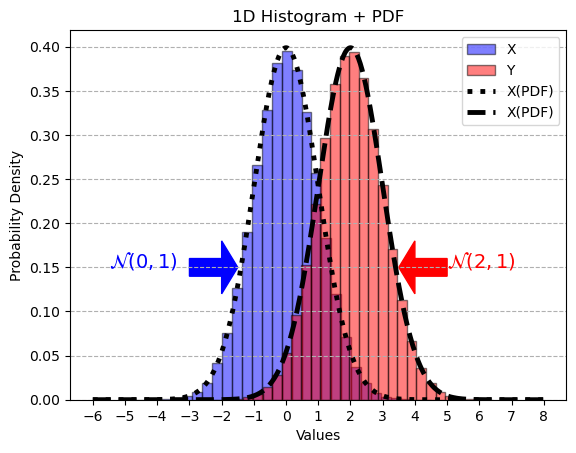

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

plt.hist(X, bins = 30, alpha=0.5, density = True, label='X', color = 'b', edgecolor = 'k')
plt.hist(Y, bins = 30, alpha=0.5, density = True, label='Y', color = 'r', edgecolor = 'k')
x_vals = np.linspace(-6, 8, 500)
PDF_X = scipy.stats.norm.pdf(x_vals, loc = 0, scale = 1)
PDF_Y = scipy.stats.norm.pdf(x_vals, loc = 2, scale = 1)

plt.plot(x_vals, PDF_X, 'k:', linewidth = 3.5, label = 'X(PDF)')
plt.plot(x_vals, PDF_Y, 'k--', linewidth = 3.5, label = 'X(PDF)')
plt.grid(axis = 'y', linestyle='--')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.xticks(np.arange(-6, 9, 1))
plt.title('1D Histogram + PDF')
plt.text(5, 0.15, r"$\mathcal{N}(2,1)$", fontsize=14, color = 'r')
plt.arrow(x = -3, y = 0.15, dx = 1, dy = 0, color = 'blue', width = 0.02, head_length = 0.5)
plt.arrow(x = 5, y = 0.15, dx = -1, dy = 0, color = 'red', width = 0.02, head_length = 0.5)
plt.text(-5.5, 0.15, r"$\mathcal{N}(0,1)$", fontsize=14, color = 'b')
plt.legend()
plt.show()

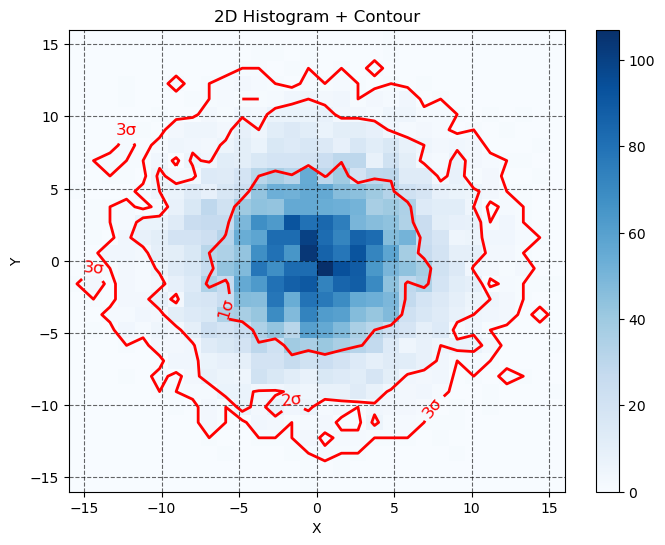

In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ---------------------------------------------------
# 1) REQUIRED: generate 100000 points
# ---------------------------------------------------
N = 100000
x_all = np.random.normal(0, 1, N)   # X ~ N(0,1)
y_all = np.random.normal(2, 1, N)   # Y ~ N(2,1)

# ---------------------------------------------------
# 2) For the PLOT, use a smaller random subset
#    (This makes the histogram + contours look like the example)
# ---------------------------------------------------
N_plot = 10000
idx = np.random.choice(N, N_plot, replace=False)

x = x_all[idx]
y = y_all[idx]

# ---------------------------------------------------
# 3) Make it match the example's spread & center
#    - spread like sigma ~ 5
#    - center at (0,0)
# ---------------------------------------------------
x = 4.5 * x
y = 4.25 * (y - 2)

# ---------------------------------------------------
# 4) 2D histogram (bins=30 is REQUIRED)
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

counts, xedges, yedges, im = ax.hist2d(
    x, y,
    bins=30,                      # REQUIRED
    range=[[-16, 16], [-16, 16]], # matches example axes
    cmap="Blues"
)

plt.colorbar(im, ax=ax)

# ---------------------------------------------------
# 5) Find 1σ / 2σ / 3σ contour levels WITHOUT np.cumsum()
# ---------------------------------------------------
values = counts.flatten()         # 30x30 grid -> 1 long list
values = np.sort(values)[::-1]    # biggest bins first
total = np.sum(values)            # total points in the histogram

levels = []
for p in [0.68, 0.95, 0.997]:
    running = 0
    for v in values:
        running += v
        if running / total >= p:
            levels.append(v)
            break

levels = sorted(levels)  # contour() needs increasing levels

# ---------------------------------------------------
# 6) Bin centers for contour plotting
# ---------------------------------------------------
xc = (xedges[:-1] + xedges[1:]) / 2
yc = (yedges[:-1] + yedges[1:]) / 2
Xc, Yc = np.meshgrid(xc, yc)

# ---------------------------------------------------
# 7) Plot contours + labels
# ---------------------------------------------------
cs = ax.contour(Xc, Yc, counts.T, levels=levels, colors="red", linewidths=2)
ax.clabel(cs, fmt={levels[0]:"3σ", levels[1]:"2σ", levels[2]:"1σ"}, fontsize=12)

# ---------------------------------------------------
# 8) Styling to match the example
# ---------------------------------------------------
ax.set_title("2D Histogram + Contour")
ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_xlim(-16, 16)
ax.set_ylim(-16, 16)

ax.set_xticks(np.arange(-15, 16, 5))
ax.set_yticks(np.arange(-15, 16, 5))

ax.grid(True, linestyle="--", color="black", alpha=0.6)

plt.show()